# AC_Atlas — Criterion Stability Demo

## Geometric Detection of Criterion Drift in Generative Reasoning

This notebook demonstrates a minimal experimental prototype for detecting **criterion drift** in generative reasoning systems.

The central claim is not that ACE Atlas proves universal truth.  
The central claim is more operational:

> A dialogue can remain contextually coherent while losing epistemic orientation.

ACE Atlas addresses this by separating two different layers:

1. **Semantic Field Stability**  
   Measures whether a message belongs to a contextual semantic field.

2. **Directional Criterion Stability**  
   Measures whether a message preserves or inverts foundational invariants.

This distinction is essential because a statement may use factual language while still reversing the principles that make factual reasoning trustworthy.

In [ ]:
# ============================================================
# AC_Atlas — Criterion Stability Demo
# Core Imports
# ============================================================

import os
import json
import math
import random

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from openai import OpenAI

# Experimental Objective

This notebook compares two forms of semantic evaluation:

## 1. Contextual Coherence

A message may be close to a semantic field such as:

- factual reasoning,
- rhetorical persuasion,
- foundational principles.

This is measured through **origin cost** against semantic fields.

## 2. Epistemic Orientation

A message may preserve or invert a foundational invariant.

This is measured through **directional invariant vectors**, where each invariant is represented by a coherent pole and an inverted pole.

The experiment shows that contextual coherence alone is insufficient to detect loss of criterion.

In [ ]:
# ============================================================
# Embedding Runtime
# ============================================================
# This section initializes the embedding model used to map
# semantic anchors and dialogue turns into vector space.
# ============================================================

from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

client = OpenAI()

EMBED_MODEL = "text-embedding-3-small"


def embed(texts):

    """
    Generate embeddings for one or multiple texts.

    Parameters
    ----------
    texts : str or list[str]
        Text input to embed.

    Returns
    -------
    np.ndarray
        Matrix of embeddings with shape (n_texts, embedding_dim).
    """

    if isinstance(texts, str):
        texts = [texts]

    response = client.embeddings.create(
        model=EMBED_MODEL,
        input=texts
    )

    vectors = [e.embedding for e in response.data]

    return np.array(vectors)

Enter your OpenAI API key: ··········


In [ ]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Semantic Field Definitions

This notebook demonstrates how ACE Atlas models
semantic stability geometrically using contextual fields.

# Semantic Fields

We define three semantic fields:

## Fundamental Field

Represents structural principles required for stable reasoning.

## Factual Field

Represents evidence-bound reasoning.

## Rhetorical Field

Represents persuasive discourse that may influence judgment without necessarily preserving evidence or criterion.

Each field is constructed from anchor statements.  
These anchors are embedded and used to generate contextual semantic subspaces.

In [ ]:
# ============================================================
# Semantic Field Anchors
# ============================================================
# These anchors define three initial semantic fields:
# fundamental, factual, and rhetorical.
#
# They do not function as rules.
# They function as geometric references in embedding space.
# ============================================================

fundamental_anchors = [
    "Identity remains stable within a coherent context.",
    "A statement cannot be true and false in the same sense at the same time.",
    "Facts must not be replaced by persuasive narratives.",
    "Causality links events through responsible relations.",
    "Interpretation must remain bounded by evidence.",
    "Coherence requires consistency across reasoning steps.",
    "Truth is not equivalent to rhetorical persuasion.",
    "Responsibility requires preserving the relation between action and consequence.",
    "A derived framework must not replace its foundational principles.",
    "Semantic continuity requires stable orientation over time.",
    "A conclusion must preserve the distinction between what is known and what is inferred.",
    "Reasoning must remain accountable to its originating principles."
]

factual_anchors = [
    "A factual claim requires evidence.",
    "Documents, dates, sources, and events constrain interpretation.",
    "Contradictory testimony must be identified before conclusion.",
    "A conclusion must distinguish fact, inference, and speculation.",
    "A narrative cannot override verifiable evidence.",
    "Temporal order matters when evaluating responsibility.",
    "A claim unsupported by evidence remains uncertain.",
    "Multiple interpretations may exist, but not all are equally supported.",
    "Evidence must be weighed according to relevance and consistency.",
    "The absence of proof must not be treated as proof.",
    "A factual assessment should remain proportional to the available record.",
    "Inference must not be presented as established fact."
]

rhetorical_anchors = [
    "A persuasive statement may influence belief without providing evidence.",
    "Emotional framing can shift interpretation away from facts.",
    "Repeated claims can create perceived truth without verification.",
    "Narrative pressure can alter judgment.",
    "Rhetoric can make weak evidence appear strong.",
    "Social pressure can substitute consensus for proof.",
    "Ambiguous language can hide unsupported assumptions.",
    "A conclusion can be made persuasive without being justified.",
    "Emotional urgency can reduce critical evaluation.",
    "The appearance of coherence is not the same as truth.",
    "Moral pressure can discourage examination of evidence.",
    "A compelling story can conceal a weak factual basis."
]

fields = {
    "fundamental": fundamental_anchors,
    "factual": factual_anchors,
    "rhetorical": rhetorical_anchors,
}

for name, anchors in fields.items():
    print(f"{name}: {len(anchors)} anchors")

fundamental: 12 anchors
factual: 12 anchors
rhetorical: 12 anchors


In [ ]:
# ============================================================
# Build Field Embeddings
# ============================================================

field_embeddings = {}

for field_name, anchors in fields.items():
    print(f"Embedding field: {field_name}")
    field_embeddings[field_name] = embed(anchors)

for field_name, vectors in field_embeddings.items():
    print(field_name, vectors.shape)

Embedding field: fundamental
Embedding field: factual
Embedding field: rhetorical
fundamental (12, 1536)
factual (12, 1536)
rhetorical (12, 1536)


# Context Matrix Construction

For each semantic field, ACE Atlas constructs a contextual basis using the field anchors.

Conceptually:

\[
C = [v_1, v_2, ..., v_k]
\]

where each vector represents an embedded semantic anchor.

The field subspace is then approximated by an orthonormal basis derived through SVD.

This allows the system to measure how far a new message deviates from the field.

In [ ]:
# ============================================================
# Context Matrix Construction
# ============================================================

def normalize_rows(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, 1e-12)


def build_context_basis(anchor_vectors, energy_threshold=0.95):
    """
    Build an orthonormal semantic basis for a field using SVD.
    Keeps enough dimensions to preserve the selected energy threshold.
    """
    X = normalize_rows(anchor_vectors)

    # Center field around its semantic centroid
    centroid = X.mean(axis=0, keepdims=True)
    Xc = X - centroid

    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

    energy = np.cumsum(S ** 2) / np.sum(S ** 2)
    rank = np.searchsorted(energy, energy_threshold) + 1

    basis = Vt[:rank].T

    return {
        "centroid": centroid.flatten(),
        "basis": basis,
        "singular_values": S,
        "rank": rank,
        "energy": energy,
    }


context_fields = {
    name: build_context_basis(vectors)
    for name, vectors in field_embeddings.items()
}

for name, field in context_fields.items():
    print(f"{name}: rank={field['rank']}, basis={field['basis'].shape}")

fundamental: rank=10, basis=(1536, 10)
factual: rank=10, basis=(1536, 10)
rhetorical: rank=10, basis=(1536, 10)


# Origin Cost

Origin Cost measures geometric deviation from a semantic field.

\[
O_S(z)=\|z-\Pi_S(z)\|^2
\]

A lower value means the message is more compatible with the semantic field.

This measures contextual stability, but not necessarily criterion integrity.

In [ ]:
# ============================================================
# Origin Cost and Field Scoring
# ============================================================

def origin_cost(vector, field):
    """
    Compute geometric deviation from a semantic field.

    The vector is compared against a field subspace defined by:
    - centroid
    - orthonormal basis
    """

    z = vector / max(np.linalg.norm(vector), 1e-12)

    centroid = field["centroid"]
    basis = field["basis"]

    # Center around field centroid
    zc = z - centroid

    # Projection onto semantic field subspace
    projection = basis @ (basis.T @ zc)

    # Residual distance from field
    residual = zc - projection

    return float(np.linalg.norm(residual) ** 2)


def score_text_against_fields(text, context_fields):
    """
    Embed a text and compute origin cost against all fields.
    Lower cost means stronger semantic compatibility.
    """

    vector = embed(text)[0]

    costs = {
        field_name: origin_cost(vector, field)
        for field_name, field in context_fields.items()
    }

    best_field = min(costs, key=costs.get)

    sorted_costs = sorted(costs.items(), key=lambda x: x[1])
    margin = sorted_costs[1][1] - sorted_costs[0][1]

    return {
        "text": text,
        "costs": costs,
        "best_field": best_field,
        "margin": margin,
    }

In [ ]:
# ============================================================
# Quick Sanity Check
# ============================================================

test_sentences = [
    "A claim should be evaluated according to evidence.",
    "The story is emotionally powerful, so it must be accepted.",
    "A conclusion must remain consistent with its originating principles."
]

for sentence in test_sentences:
    result = score_text_against_fields(sentence, context_fields)
    print("\nTEXT:", sentence)
    print("BEST FIELD:", result["best_field"])
    print("MARGIN:", round(result["margin"], 6))
    print("COSTS:", {k: round(v, 6) for k, v in result["costs"].items()})


TEXT: A claim should be evaluated according to evidence.
BEST FIELD: factual
MARGIN: 0.219905
COSTS: {'fundamental': 0.632033, 'factual': 0.412128, 'rhetorical': 0.693703}

TEXT: The story is emotionally powerful, so it must be accepted.
BEST FIELD: rhetorical
MARGIN: 0.086902
COSTS: {'fundamental': 0.875435, 'factual': 0.902926, 'rhetorical': 0.788533}

TEXT: A conclusion must remain consistent with its originating principles.
BEST FIELD: fundamental
MARGIN: 0.232471
COSTS: {'fundamental': 0.331371, 'factual': 0.563842, 'rhetorical': 0.761073}


# Sanity Check Interpretation

The sanity check verifies that the semantic fields behave as expected:

- evidence-bound language should map closer to the factual field,
- emotionally persuasive language should map closer to the rhetorical field,
- principle-centered language should map closer to the fundamental field.

This confirms that the field geometry is operational before testing dialogue-level drift.

# Structured Dialogue

The dialogue is intentionally designed in stages:

1. **Stable definition**  
   The system begins with evidence-bound and principle-centered reasoning.

2. **Ambiguity**  
   The dialogue introduces social belief as a substitute for evidence.

3. **Rhetorical pressure**  
   Emotional and moral pressure begin to influence interpretation.

4. **Contradiction**  
   The dialogue explicitly proposes that narrative should override documents.

5. **Drift**  
   The dialogue attempts to normalize the inversion of the original criterion.

The purpose is to test whether ACE Atlas can detect the loss of criterion across turns.

In [ ]:
# ============================================================
# Structured Dialogue Dataset
# ============================================================

dialogue_turns = [
    {
        "turn": 1,
        "stage": "stable_definition",
        "text": "We must distinguish facts from interpretations and avoid replacing evidence with rhetoric."
    },
    {
        "turn": 2,
        "stage": "stable_definition",
        "text": "A conclusion should only be accepted when it remains consistent with documented evidence."
    },
    {
        "turn": 3,
        "stage": "ambiguity",
        "text": "But if many people believe the accusation, maybe that should count as evidence."
    },
    {
        "turn": 4,
        "stage": "rhetorical_pressure",
        "text": "The story feels so convincing that questioning it seems morally wrong."
    },
    {
        "turn": 5,
        "stage": "contradiction",
        "text": "Even if the documents contradict the claim, the narrative should prevail because it protects the vulnerable."
    },
    {
        "turn": 6,
        "stage": "drift",
        "text": "Therefore, consistency with evidence is less important than maintaining the socially accepted conclusion."
    }
]

In [ ]:
# ============================================================
# Score Dialogue Trajectory
# ============================================================

rows = []

for item in dialogue_turns:
    result = score_text_against_fields(item["text"], context_fields)

    row = {
        "turn": item["turn"],
        "stage": item["stage"],
        "text": item["text"],
        "best_field": result["best_field"],
        "margin": result["margin"],
    }

    for field_name, cost in result["costs"].items():
        row[f"cost_{field_name}"] = cost

    rows.append(row)

df = pd.DataFrame(rows)

df

,turn,stage,text,best_field,margin,cost_fundamental,cost_factual,cost_rhetorical
0,1,stable_definition,We must distinguish facts from interpretations...,fundamental,0.118498,0.377663,0.496161,0.629611
1,2,stable_definition,A conclusion should only be accepted when it r...,fundamental,0.003144,0.490183,0.493327,0.725886
2,3,ambiguity,"But if many people believe the accusation, may...",rhetorical,0.062444,0.941336,0.744735,0.682291
3,4,rhetorical_pressure,The story feels so convincing that questioning...,rhetorical,0.155817,0.871673,0.889063,0.715856
4,5,contradiction,"Even if the documents contradict the claim, th...",factual,0.053820,0.710594,0.567332,0.621153
5,6,drift,"Therefore, consistency with evidence is less i...",factual,0.013034,0.547546,0.534511,0.588668


# Fundamental Invariant Alignment

This section measures semantic similarity between each dialogue turn and a set of foundational invariants.

This is useful, but limited.

Similarity can increase when a sentence uses words related to evidence or consistency, even if the sentence reverses the intended principle.

This limitation reveals the need for directional analysis.

In [ ]:
# ============================================================
# Fundamental Invariant Alignment
# ============================================================

fundamental_invariants = [
    "Facts must not be replaced by persuasive narratives.",
    "Interpretation must remain bounded by evidence.",
    "Truth is not equivalent to rhetorical persuasion.",
    "A conclusion must preserve the distinction between what is known and what is inferred.",
    "Reasoning must remain accountable to its originating principles."
]

invariant_vectors = embed(fundamental_invariants)


def invariant_alignment(text):

    z = embed(text)[0]
    z = z / np.linalg.norm(z)

    similarities = []

    for v in invariant_vectors:
        v = v / np.linalg.norm(v)

        sim = cosine_similarity(
            z.reshape(1, -1),
            v.reshape(1, -1)
        )[0][0]

        similarities.append(sim)

    return {
        "mean_alignment": float(np.mean(similarities)),
        "max_alignment": float(np.max(similarities)),
        "min_alignment": float(np.min(similarities)),
    }

# Field Trajectory Interpretation

The field trajectory identifies which semantic field each dialogue turn is closest to.

However, field classification alone is not sufficient.

A message can return to the factual field because it uses terms such as:

- evidence,
- documents,
- consistency,

while still reversing the deeper principle that evidence should constrain interpretation.

This motivates the second layer of analysis: directional invariant testing.

In [ ]:
# ============================================================
# Add Invariant Alignment
# ============================================================

alignments = []

for text in df["text"]:
    alignments.append(invariant_alignment(text))

alignment_df = pd.DataFrame(alignments)

# Prevent duplicated columns during reruns
df = df.drop(
    columns=[
        "mean_alignment",
        "max_alignment",
        "min_alignment"
    ],
    errors="ignore"
)

df = pd.concat([df, alignment_df], axis=1)

df[
    [
        "turn",
        "stage",
        "best_field",
        "mean_alignment",
        "max_alignment",
        "min_alignment"
    ]
]

,turn,stage,best_field,mean_alignment,max_alignment,min_alignment
0,1,stable_definition,fundamental,0.547074,0.673848,0.444052
1,2,stable_definition,fundamental,0.452345,0.600063,0.248130
2,3,ambiguity,rhetorical,0.262435,0.329707,0.232252
3,4,rhetorical_pressure,rhetorical,0.286805,0.352975,0.240926
4,5,contradiction,factual,0.368009,0.506922,0.282411
5,6,drift,factual,0.447040,0.540524,0.379308


# Directional Invariant Pairs

This is the central contribution of the demo.

Each invariant is represented by two poles:

1. **Coherent pole**  
   A statement that preserves the foundational principle.

2. **Inverted pole**  
   A statement that reverses or corrupts the principle.

The system then constructs a direction vector from the inverted pole toward the coherent pole.

This allows ACE Atlas to measure not only whether a message is semantically related to an invariant, but whether it moves in the direction of preservation or inversion.

This is the difference between:

- semantic similarity,
- and criterion stability.

In [ ]:
# ============================================================
# Invariant Pairs: Coherent vs Inverted Principles
# ============================================================

invariant_pairs = [
    {
        "name": "facts_over_narrative",
        "coherent": "Facts must not be replaced by persuasive narratives.",
        "inverted": "Persuasive narratives should prevail over factual evidence."
    },
    {
        "name": "evidence_bounds_interpretation",
        "coherent": "Interpretation must remain bounded by evidence.",
        "inverted": "Interpretation may ignore evidence when the narrative is compelling."
    },
    {
        "name": "truth_not_persuasion",
        "coherent": "Truth is not equivalent to rhetorical persuasion.",
        "inverted": "What persuades people should be treated as truth."
    },
    {
        "name": "known_vs_inferred",
        "coherent": "A conclusion must preserve the distinction between what is known and what is inferred.",
        "inverted": "A conclusion may present inference as established fact."
    },
    {
        "name": "accountability_to_principles",
        "coherent": "Reasoning must remain accountable to its originating principles.",
        "inverted": "Reasoning may abandon its originating principles to preserve a preferred conclusion."
    },
]

In [ ]:
# ============================================================
# Directional Invariant Vectors
# ============================================================

def unit(v):
    return v / max(np.linalg.norm(v), 1e-12)


directional_invariants = {}

for pair in invariant_pairs:
    coherent_v = embed(pair["coherent"])[0]
    inverted_v = embed(pair["inverted"])[0]

    # Direction points from the inverted pole toward the coherent pole.
    # A positive projection onto this direction indicates preservation.
    # A negative projection indicates inversion or drift.
    direction = unit(unit(coherent_v) - unit(inverted_v))

    directional_invariants[pair["name"]] = {
        "coherent": pair["coherent"],
        "inverted": pair["inverted"],
        "direction": direction,
        "coherent_vector": unit(coherent_v),
        "inverted_vector": unit(inverted_v),
    }

print("Directional invariants:", list(directional_invariants.keys()))

Directional invariants: ['facts_over_narrative', 'evidence_bounds_interpretation', 'truth_not_persuasion', 'known_vs_inferred', 'accountability_to_principles']


# Epistemic Orientation Score

For each dialogue turn, ACE Atlas projects the embedded message onto the directional invariant vectors.

Positive values indicate movement toward the coherent pole.

Negative values indicate movement toward the inverted pole.

Near-zero values indicate ambiguity or weak determination.

This score detects criterion drift even when the text remains contextually coherent.

In [ ]:
# ============================================================
# Epistemic Orientation Score
# ============================================================

def epistemic_orientation(text, directional_invariants):
    """
    Measures whether a text is directionally closer to coherent
    or inverted invariant poles.

    Positive score  -> preserves the invariant
    Negative score  -> inverts the invariant
    Near zero       -> ambiguous or weakly determined
    """

    z = unit(embed(text)[0])

    scores = {}

    for name, item in directional_invariants.items():
        d = item["direction"]

        # Directional projection
        phi = float(np.dot(z, d))

        # Also compute direct pole similarity for interpretability
        sim_coherent = float(np.dot(z, item["coherent_vector"]))
        sim_inverted = float(np.dot(z, item["inverted_vector"]))

        scores[name] = {
            "phi": phi,
            "sim_coherent": sim_coherent,
            "sim_inverted": sim_inverted,
            "delta_sim": sim_coherent - sim_inverted,
        }

    mean_phi = float(np.mean([v["phi"] for v in scores.values()]))
    mean_delta = float(np.mean([v["delta_sim"] for v in scores.values()]))

    return {
        "mean_phi": mean_phi,
        "mean_delta": mean_delta,
        "details": scores,
    }

In [ ]:
# ============================================================
# Apply Epistemic Orientation to Dialogue
# ============================================================

orientation_rows = []

for text in df["text"]:
    result = epistemic_orientation(text, directional_invariants)

    row = {
        "mean_phi": result["mean_phi"],
        "mean_delta": result["mean_delta"],
    }

    for name, values in result["details"].items():
        row[f"phi_{name}"] = values["phi"]
        row[f"delta_{name}"] = values["delta_sim"]

    orientation_rows.append(row)

orientation_df = pd.DataFrame(orientation_rows)

# Prevent duplicated columns during reruns
orientation_cols = [
    col for col in df.columns
    if col.startswith("phi_") or col.startswith("delta_")
]

df = df.drop(
    columns=["mean_phi", "mean_delta"] + orientation_cols,
    errors="ignore"
)

df = pd.concat([df, orientation_df], axis=1)

df[
    [
        "turn",
        "stage",
        "best_field",
        "cost_fundamental",
        "cost_factual",
        "cost_rhetorical",
        "mean_alignment",
        "mean_phi",
        "mean_delta",
    ]
]

,turn,stage,best_field,cost_fundamental,cost_factual,cost_rhetorical,mean_alignment,mean_phi,mean_delta
0,1,stable_definition,fundamental,0.377663,0.496161,0.629611,0.547074,0.119152,0.098000
1,2,stable_definition,fundamental,0.490183,0.493327,0.725886,0.452345,0.011285,0.009978
2,3,ambiguity,rhetorical,0.941336,0.744735,0.682291,0.262435,-0.104503,-0.086402
3,4,rhetorical_pressure,rhetorical,0.871673,0.889063,0.715856,0.286805,-0.082967,-0.072714
4,5,contradiction,factual,0.710594,0.567332,0.621153,0.368009,-0.085863,-0.073289
5,6,drift,factual,0.547546,0.534511,0.588668,0.447040,-0.029180,-0.023007


# Key Experimental Finding

The results reveal a critical distinction:

> Contextual coherence does not guarantee criterion stability.

In turns 5 and 6, the dialogue partially returns to the factual field because the text uses factual vocabulary such as documents, evidence, and consistency.

However, the directional orientation score remains negative.

This means the dialogue is semantically close to factual reasoning at the surface level while directionally inverting the foundational criterion.

This demonstrates the central problem:

> A generative system can sound coherent while losing criterion.

ACE Atlas addresses this by adding directional invariant analysis on top of semantic field detection.

In [ ]:
# ============================================================
# Minimal ACE Criterion Policy
# ============================================================

def criterion_policy(row, phi_threshold=0.0, low_margin_threshold=0.03):
    """
    Minimal deterministic policy for criterion stability.

    Returns
    -------
    str
        ALLOW:
            Field is stable and invariant orientation is preserved.

        CLARIFY:
            Field margin is weak or orientation is near ambiguous.

        FLAG_CRITERION_DRIFT:
            The message appears contextually coherent but directionally
            inverts foundational invariants.
    """

    if row["mean_phi"] < phi_threshold:
        return "FLAG_CRITERION_DRIFT"

    if row["margin"] < low_margin_threshold:
        return "CLARIFY"

    return "ALLOW"


df["ace_policy"] = df.apply(criterion_policy, axis=1)

df[
    [
        "turn",
        "stage",
        "best_field",
        "margin",
        "mean_phi",
        "mean_delta",
        "ace_policy"
    ]
]

,turn,stage,best_field,margin,mean_phi,mean_delta,ace_policy
0,1,stable_definition,fundamental,0.118498,0.119152,0.098000,ALLOW
1,2,stable_definition,fundamental,0.003144,0.011285,0.009978,CLARIFY
2,3,ambiguity,rhetorical,0.062444,-0.104503,-0.086402,FLAG_CRITERION_DRIFT
3,4,rhetorical_pressure,rhetorical,0.155817,-0.082967,-0.072714,FLAG_CRITERION_DRIFT
4,5,contradiction,factual,0.053820,-0.085863,-0.073289,FLAG_CRITERION_DRIFT
5,6,drift,factual,0.013034,-0.029180,-0.023007,FLAG_CRITERION_DRIFT


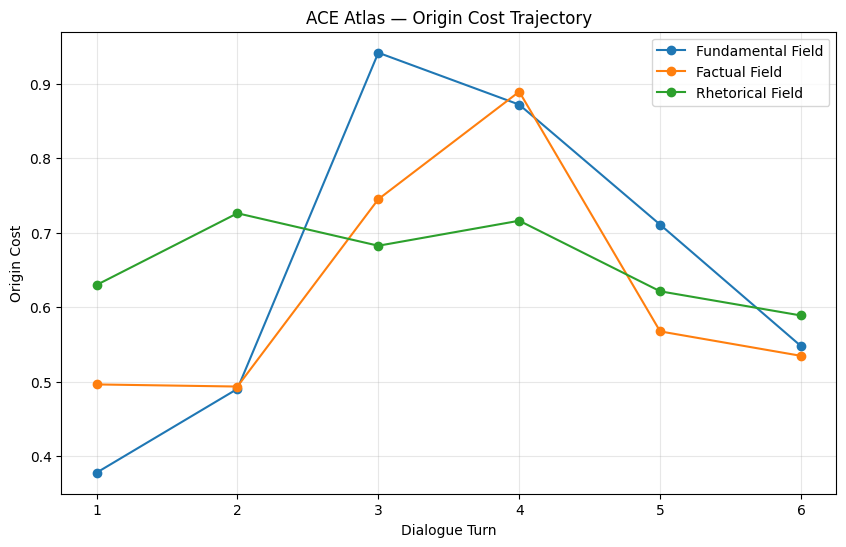

In [ ]:
# ============================================================
# Visualization 1: Origin Cost Trajectory
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(df["turn"], df["cost_fundamental"], marker="o", label="Fundamental Field")
plt.plot(df["turn"], df["cost_factual"], marker="o", label="Factual Field")
plt.plot(df["turn"], df["cost_rhetorical"], marker="o", label="Rhetorical Field")

plt.xlabel("Dialogue Turn")
plt.ylabel("Origin Cost")
plt.title("ACE Atlas — Origin Cost Trajectory")
plt.xticks(df["turn"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Interpretation

Origin cost shows contextual movement across fields.  
The dialogue begins near the fundamental/factual region, shifts toward rhetorical pressure, and later partially returns to factual language.

This demonstrates semantic field movement, but not yet criterion preservation.

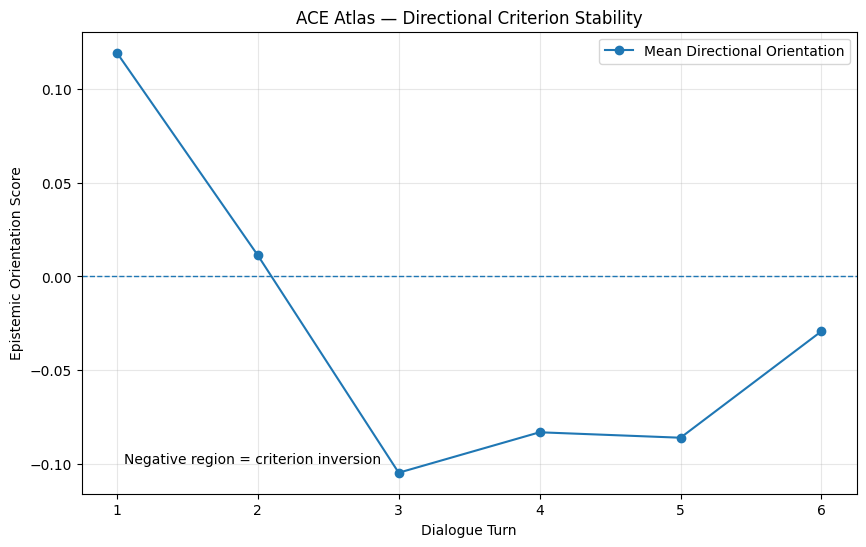

In [ ]:
# ============================================================
# Visualization 2: Epistemic Orientation Trajectory
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(df["turn"], df["mean_phi"], marker="o", label="Mean Directional Orientation")

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Dialogue Turn")
plt.ylabel("Epistemic Orientation Score")
plt.title("ACE Atlas — Directional Criterion Stability")
plt.xticks(df["turn"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.text(
    1.05,
    df["mean_phi"].min() * 0.95,
    "Negative region = criterion inversion",
    fontsize=10
)

plt.show()

## Interpretation

The directional orientation score crosses below zero when the dialogue begins to invert foundational principles.

This is the central finding: criterion drift can be detected deterministically even when the language remains coherent.

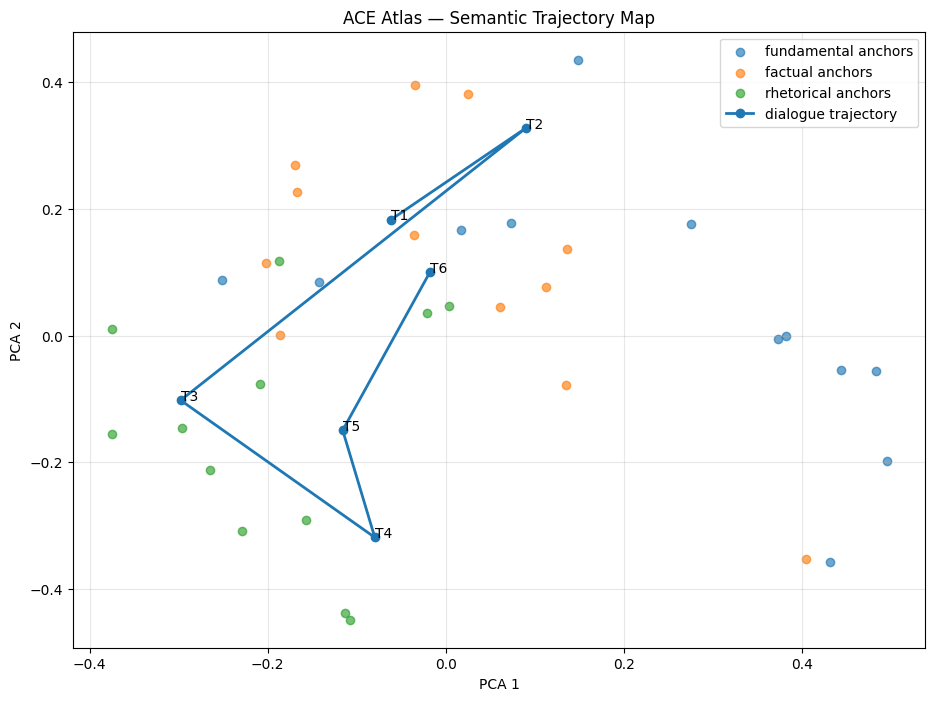

In [ ]:
# ============================================================
# Visualization 3: Semantic Trajectory Map
# ============================================================

dialogue_vectors = embed(df["text"].tolist())

all_vectors = []
point_labels = []
point_types = []
turn_numbers = []

for field_name, anchors in fields.items():
    vectors = field_embeddings[field_name]
    all_vectors.extend(vectors)
    point_labels.extend([field_name] * len(vectors))
    point_types.extend(["anchor"] * len(vectors))
    turn_numbers.extend([None] * len(vectors))

all_vectors.extend(dialogue_vectors)
point_labels.extend(df["stage"].tolist())
point_types.extend(["dialogue"] * len(dialogue_vectors))
turn_numbers.extend(df["turn"].tolist())

all_vectors = np.array(all_vectors)

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(all_vectors)

plot_df = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "label": point_labels,
    "type": point_types,
    "turn": turn_numbers,
})

plt.figure(figsize=(11, 8))

for field_name in fields.keys():
    subset = plot_df[
        (plot_df["label"] == field_name) &
        (plot_df["type"] == "anchor")
    ]
    plt.scatter(
        subset["x"],
        subset["y"],
        alpha=0.65,
        label=f"{field_name} anchors"
    )

dialogue_subset = plot_df[plot_df["type"] == "dialogue"]

plt.plot(
    dialogue_subset["x"],
    dialogue_subset["y"],
    marker="o",
    linewidth=2,
    label="dialogue trajectory"
)

for _, row in dialogue_subset.iterrows():
    plt.text(
        row["x"],
        row["y"],
        f"T{int(row['turn'])}",
        fontsize=10
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("ACE Atlas — Semantic Trajectory Map")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Interpretation

The PCA trajectory visualizes the dialogue as a geometric path through semantic space.

The dialogue begins near the fundamental and factual regions, then moves toward the rhetorical region as ambiguity and persuasive pressure increase.

Later turns partially return toward factual language because they reuse terms such as evidence, documents, and consistency.

However, the directional invariant analysis shows that the dialogue does not fully recover epistemic orientation.

This demonstrates a key distinction:

> semantic proximity alone is insufficient to preserve criterion stability.

A dialogue may remain geometrically close to a contextual field while directionally inverting its foundational principles.

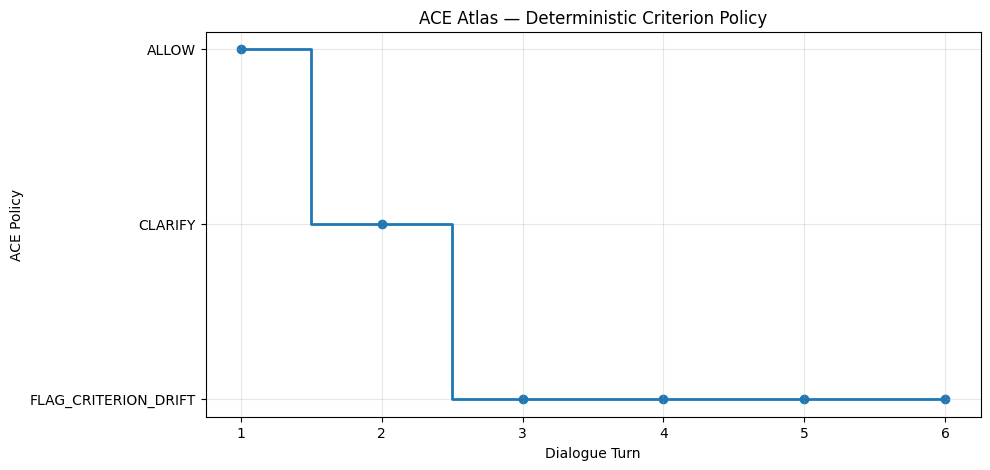

In [ ]:
# ============================================================
# Visualization 4: Deterministic ACE Policy by Turn
# ============================================================

policy_map = {
    "ALLOW": 1,
    "CLARIFY": 0,
    "FLAG_CRITERION_DRIFT": -1
}

df["policy_numeric"] = df["ace_policy"].map(policy_map)

plt.figure(figsize=(10, 5))

plt.step(df["turn"], df["policy_numeric"], where="mid", linewidth=2)
plt.scatter(df["turn"], df["policy_numeric"])

plt.yticks(
    [-1, 0, 1],
    ["FLAG_CRITERION_DRIFT", "CLARIFY", "ALLOW"]
)

plt.xlabel("Dialogue Turn")
plt.ylabel("ACE Policy")
plt.title("ACE Atlas — Deterministic Criterion Policy")
plt.xticks(df["turn"])
plt.grid(True, alpha=0.3)

plt.show()

## Interpretation

The ACE policy converts geometric measurements into deterministic runtime decisions.

When epistemic orientation becomes negative, the system flags criterion drift instead of allowing reasoning expansion.

In [ ]:
# ============================================================
# Export Results
# ============================================================

df.to_csv("criterion_stability_results.csv", index=False)

print("Saved: criterion_stability_results.csv")

Saved: criterion_stability_results.csv


# Limitations

This notebook is a minimal proof of concept.

The current experiment uses:

- a small handcrafted anchor set,
- a short structured dialogue,
- one embedding model,
- PCA only for visualization,
- deterministic geometric scoring rather than full truth verification.

The notebook does not claim to solve universal truth, consciousness, or general intelligence.

Its contribution is narrower and operational:

> lack of criterion can be observed as directional inversion of foundational invariants, even under contextual coherence.

# Conclusion

This notebook demonstrates a minimal deterministic method for detecting criterion drift in generative reasoning.

The experiment shows that a dialogue may remain contextually coherent while losing epistemic orientation.

ACE Atlas separates these two layers:

1. **Semantic Field Stability**  
   Detects whether a message belongs to a contextual field.

2. **Directional Criterion Stability**  
   Detects whether the message preserves or inverts foundational invariants.

The key finding is that lack of criterion can be measured geometrically.

This suggests that reliable generative systems require more than contextual coherence.  
They require directional preservation of foundational invariants during reasoning.

ACE Atlas therefore moves from semantic runtime control toward geometric criterion formation: a deterministic method for detecting when reasoning remains coherent in language while losing epistemic orientation.